In [1]:
!pip install timm -q
!git clone https://github.com/emanhamed/Houses-dataset.git

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import timm
import os
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)

print(f"GPU: {torch.cuda.is_available()}")

Cloning into 'Houses-dataset'...
remote: Enumerating objects: 2166, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 2166 (delta 0), reused 0 (delta 0), pack-reused 2165 (from 1)
Receiving objects: 100% (2166/2166), 176.26 MiB | 34.71 MiB/s, done.
Resolving deltas: 100% (20/20), done.
GPU: True


In [2]:
IMG_DIR = "Houses-dataset/Houses Dataset/"
IMG_TYPES = ['frontal', 'bedroom', 'bathroom', 'kitchen']

df = pd.read_csv(
    "Houses-dataset/Houses Dataset/HousesInfo.txt",
    header=None, sep=' ',
    names=['bedrooms', 'bathrooms', 'area', 'zipcode', 'price']
)

y = np.log1p(df['price'].values)
tab_features = df[['bedrooms', 'bathrooms', 'area', 'zipcode']].values
scaler = StandardScaler()
tab_features = scaler.fit_transform(tab_features)

all_indices = np.arange(len(df))
idx_train, idx_temp = train_test_split(all_indices, test_size=0.3, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=42)

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print("Data loaded")

Train: 374 | Val: 80 | Test: 81
Data loaded


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class MultimodalHouseDataset(Dataset):
    def __init__(self, indices, tab_features, targets, img_dir, transform):
        self.indices      = indices
        self.tab_features = tab_features
        self.targets      = targets
        self.img_dir      = img_dir
        self.transform    = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        house_idx = self.indices[idx]
        imgs = []
        for img_type in IMG_TYPES:
            path = os.path.join(self.img_dir, f"{house_idx+1}_{img_type}.jpg")
            img = Image.open(path).convert('RGB')
            imgs.append(self.transform(img))
        img_tensor = torch.stack(imgs).mean(dim=0)
        tab_tensor = torch.FloatTensor(self.tab_features[house_idx])
        target     = torch.tensor(self.targets[house_idx], dtype=torch.float32)
        return img_tensor, tab_tensor, target

train_ds = MultimodalHouseDataset(idx_train, tab_features, y, IMG_DIR, transform)
val_ds   = MultimodalHouseDataset(idx_val,   tab_features, y, IMG_DIR, transform)
test_ds  = MultimodalHouseDataset(idx_test,  tab_features, y, IMG_DIR, transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print("DataLoaders ready")

DataLoaders ready


In [4]:
class LateFusionModel(nn.Module):
    def __init__(self, tab_input_dim=4):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        self.img_projector = nn.Sequential(
            nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.tab_projector = nn.Sequential(
            nn.Linear(tab_input_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 256), nn.ReLU(), nn.Dropout(0.2)
        )
        self.fusion_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        img_feat = self.img_projector(self.vit(img))
        tab_feat = self.tab_projector(tab)
        fused    = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion_head(fused).squeeze(1)

late_model = LateFusionModel().cuda()
print(f"Late Fusion parameters: {sum(p.numel() for p in late_model.parameters()):,}")
print("Late Fusion model ready")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Late Fusion parameters: 86,160,321
Late Fusion model ready


In [5]:
class EarlyFusionModel(nn.Module):
    def __init__(self, tab_input_dim=4):
        super().__init__()

        # ViT backbone — extracts patch embeddings
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        # Early fusion: project tabular features to same dim as ViT CLS token (768)
        # Then ADD to the CLS token before the final ViT processing
        self.tab_embedding = nn.Sequential(
            nn.Linear(tab_input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 768)  # match ViT hidden dim
        )

        # Shared regression head
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        # Get ViT patch tokens (before final norm)
        img_features = self.vit(img)  # (batch, 768) — CLS token output

        # Project tabular features to 768-dim
        tab_emb = self.tab_embedding(tab)  # (batch, 768)

        # Early fusion: element-wise addition of tabular embedding to image features
        # This injects structured information directly into the image representation
        fused = img_features + tab_emb  # (batch, 768)

        return self.head(fused).squeeze(1)

early_model = EarlyFusionModel().cuda()
print(f"Early Fusion parameters: {sum(p.numel() for p in early_model.parameters()):,}")
print("Early Fusion model ready")

Early Fusion parameters: 86,111,745
Early Fusion model ready


In [6]:
criterion = nn.MSELoss()

def get_optimizer(model):
    return torch.optim.AdamW([
        {'params': model.vit.parameters(), 'lr': 1e-5},
        {'params': [p for n, p in model.named_parameters() if 'vit' not in n], 'lr': 1e-4}
    ], weight_decay=1e-4)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for imgs, tabs, targets in loader:
        imgs, tabs, targets = imgs.cuda(), tabs.cuda(), targets.cuda()
        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, tabs, targets in loader:
            imgs, tabs, targets = imgs.cuda(), tabs.cuda(), targets.cuda()
            preds = model(imgs, tabs)
            loss = criterion(preds, targets)
            total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, tabs, targets in loader:
            imgs, tabs = imgs.cuda(), tabs.cuda()
            preds = model(imgs, tabs).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.numpy())
    all_preds   = np.expm1(np.array(all_preds))
    all_targets = np.expm1(np.array(all_targets))
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae  = mean_absolute_error(all_targets, all_preds)
    r2   = r2_score(all_targets, all_preds)
    print(f"\n=== {model_name} Results ===")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE:  ${mae:,.2f}")
    print(f"R²:   {r2:.4f}")
    return rmse, mae, r2

print("Training functions ready")

Training functions ready


In [7]:
EPOCHS = 30
late_train_losses, late_val_losses = [], []
best_val_loss = float('inf')
optimizer = get_optimizer(late_model)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Training Late Fusion model... (~20-30 mins)")
for epoch in range(EPOCHS):
    train_loss = train_epoch(late_model, train_loader, optimizer)
    val_loss   = eval_epoch(late_model, val_loader)
    scheduler.step()
    late_train_losses.append(train_loss)
    late_val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(late_model.state_dict(), 'best_late_fusion.pt')
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nLate Fusion training complete")
late_rmse, late_mae, late_r2 = evaluate_model(late_model, test_loader, "Late Fusion")

Training Late Fusion model... (~20-30 mins)
Epoch [5/30] Train: 2.0996 | Val: 0.6277
Epoch [10/30] Train: 1.7356 | Val: 0.4712
Epoch [15/30] Train: 1.2253 | Val: 0.4152
Epoch [20/30] Train: 1.1565 | Val: 0.4133
Epoch [25/30] Train: 1.0776 | Val: 0.4909
Epoch [30/30] Train: 1.0328 | Val: 0.4281

Late Fusion training complete

=== Late Fusion Results ===
RMSE: $274,707.43
MAE:  $190,260.78
R²:   0.3682


In [8]:
EPOCHS = 30
early_train_losses, early_val_losses = [], []
best_val_loss = float('inf')
optimizer = get_optimizer(early_model)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Training Early Fusion model... (~20-30 mins)")
for epoch in range(EPOCHS):
    train_loss = train_epoch(early_model, train_loader, optimizer)
    val_loss   = eval_epoch(early_model, val_loader)
    scheduler.step()
    early_train_losses.append(train_loss)
    early_val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(early_model.state_dict(), 'best_early_fusion.pt')
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nEarly Fusion training complete")
early_rmse, early_mae, early_r2 = evaluate_model(early_model, test_loader, "Early Fusion")

Training Early Fusion model... (~20-30 mins)
Epoch [5/30] Train: 1.3063 | Val: 0.4004
Epoch [10/30] Train: 0.9024 | Val: 0.3529
Epoch [15/30] Train: 0.7466 | Val: 0.3577
Epoch [20/30] Train: 0.6327 | Val: 0.3466
Epoch [25/30] Train: 0.5697 | Val: 0.3095
Epoch [30/30] Train: 0.5478 | Val: 0.3161

Early Fusion training complete

=== Early Fusion Results ===
RMSE: $262,252.35
MAE:  $178,031.09
R²:   0.4241


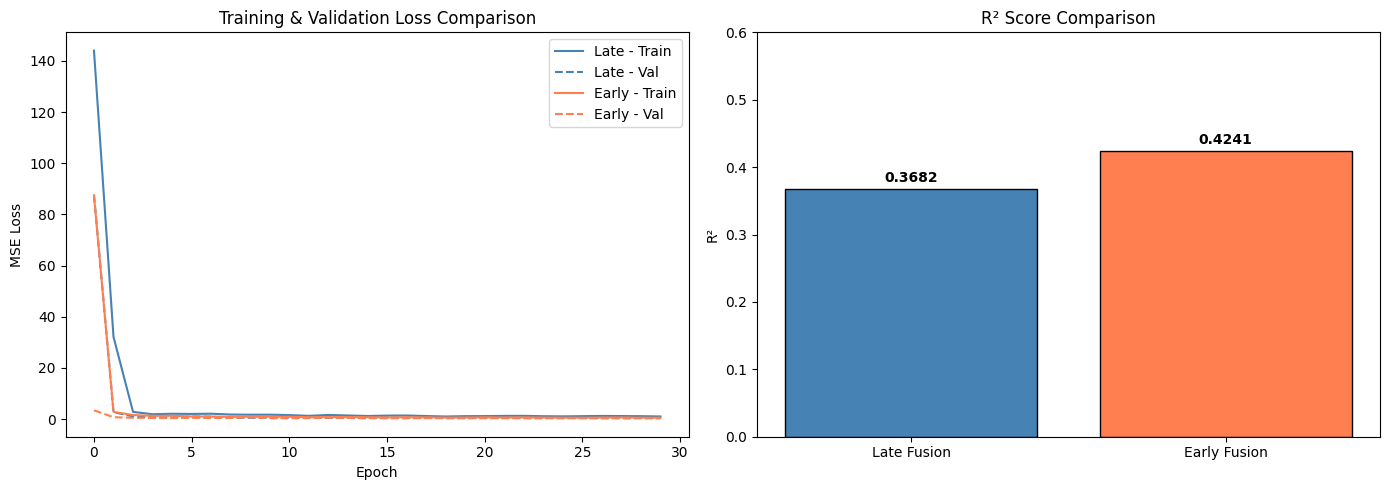


=== FINAL COMPARISON ===
Model                        RMSE          MAE       R²
--------------------------------------------------------
Late Fusion          $    274,707 $    190,261   0.3682
Early Fusion         $    262,252 $    178,031   0.4241


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(late_train_losses, label='Late - Train', color='steelblue')
axes[0].plot(late_val_losses, label='Late - Val', color='steelblue', linestyle='--')
axes[0].plot(early_train_losses, label='Early - Train', color='coral')
axes[0].plot(early_val_losses, label='Early - Val', color='coral', linestyle='--')
axes[0].set_title('Training & Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

models  = ['Late Fusion', 'Early Fusion']
r2s     = [late_r2, early_r2]
colors  = ['steelblue', 'coral']
axes[1].bar(models, r2s, color=colors, edgecolor='black')
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 0.6)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fusion_comparison.png', dpi=150)
plt.show()

print("\n=== FINAL COMPARISON ===")
print(f"{'Model':<20} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print("-" * 56)
print(f"{'Late Fusion':<20} ${late_rmse:>11,.0f} ${late_mae:>11,.0f} {late_r2:>8.4f}")
print(f"{'Early Fusion':<20} ${early_rmse:>11,.0f} ${early_mae:>11,.0f} {early_r2:>8.4f}")

In [10]:
from google.colab import files
files.download('best_late_fusion.pt')
files.download('best_early_fusion.pt')
files.download('fusion_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>